# Chasing Green E. Coli (pBILI_v2 Design)

The goal: make ec over-produce biliverdin to obtain a green color, since my previous chromoprotein-based options didn't work very well. This would be done by expressing the HO1 protein.

Then to also express [this](https://www.hfsp.org/hfsp-news/novel-biliverdin-binding-protein-responsible-green-coloration-treefrogs) protein that binds b in tree frogs, giving them their cool color.

V1: I tried just HO1 expression, using `[J23104 Promoter] - [B0034 RBS] - [Codon-Optimized ho1] -[B0015 Terminator]` in a Genscript vector. I think some biliverdin was produced but diffused out as feared, staining the whole agar plate but not giving the colonies an obvious color.

V2: I want to dial up expression (the cells seemed perfectly happy, and it took a while for color to build up) and add the tree frog protein: `[J23100 Promoter] - [B0032 RBS] - [Codon-Optimized ho1] - [B0034 RBS] - [Codon-Optimized BBS] -[B0015 Terminator]`

In [ ]:
import httpx
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

## Promoter

From https://parts.igem.org/cgi/xml/part.cgi?part=BBa_J23104 (https://parts.igem.org/Part:BBa_J23104), or switching to the stronger one

In [ ]:
J23104 = SeqRecord(Seq("ttgacagctagctcagtcctaggtattgtgctagc"),
                     id="BBa_J23104", name="J23104",
                     description="Anderson promoter J23104")
print(f"J23104: {J23104.seq}")
print(f"Length: {len(J23104)} bp")

J23104: ttgacagctagctcagtcctaggtattgtgctagc
Length: 35 bp


In [ ]:
J23100 = SeqRecord(Seq("ttgacggctagctcagtcctaggtacagtgctagc"),
                   id="BBa_J23100", name="J23100",
                   description="Anderson promoter J23100 (strongest)")
print(f"J23100: {J23100.seq}")
print(f"Length: {len(J23100)} bp")

J23100: ttgacggctagctcagtcctaggtacagtgctagc
Length: 35 bp


In [ ]:
# Checking that they are different
for a, b in zip(str(J23104.seq), str(J23100.seq)):
    if a == b: print('.', end="")
    else: print(f"[{a}, {b}]", end="")

.....[a, g]...................[t, c][t, a]........

## RBS

In [ ]:
B0034 = SeqRecord(Seq("aaagaggagaaa"), id="B0034", name="RBS_B0034", description="Ribosome binding site B0034")
B0032 = SeqRecord(Seq("tcacacaggaaag"), id="BBa_B0032", name="B0032", description="RBS B0032 (~0.3x strength of B0034)")

## Terminator(s)

In [ ]:
s = "ccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctc tactagagtcacactggctcaccttcgggtgggcctttctgcgtttata"
B0015 = SeqRecord(Seq(s.replace(' ', '')), id="B0015", name="Terminator_B0015", description="Double terminator B0015")
print(f"B0015: {B0015.seq}")
print(f"Length: {len(B0015)} bp")

B0015: ccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctctactagagtcacactggctcaccttcgggtgggcctttctgcgtttata
Length: 129 bp


## HO1

OK now for the fun bit, HO1. https://pmc.ncbi.nlm.nih.gov/articles/PMC3534565/ talks about this. They share a codon-optimized version, here I check that it does translate to the HO1 AA seq.

In [ ]:
ho1_aa = 'MSVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAMEEEMAKFKDHPILSHIYFPELNRKQSLEQDLQFYYGSNWRQEVKISAAGQAYVDRVRQVAATAPELLVAHSYTRYLGDLSGGQILKKIAQNAMNLHDGGTAFYEFADIDDEKAFKNTYRQAMNDLPIDQATAERIVDEANDAFAMNMKMFNELEGNLIKAIGIMVFNSLTRRRSQGSTEVGLATSEG'

In [ ]:
co_ho1 = """AGT GTC AAC TTA GCT TCC CAG TTG CGG GAA GGG ACG AAA AAA TCC CAC
TCC ATG GCG GAG AAC GTC GGC TTT GTC AAA TGC TTC CTC AAG GGC GTT
GTC GAG AAA AAT TCC TAC CGT AAG CTG GTT GGC AAT CTC TAC TTT GTC
TAC AGT GCC ATG GAA GAG GAA ATG GCA AAA TTT AAG GAC CAT CCC ATC
CTC AGC CAC ATT TAC TTC CCC GAA CTA AAC CGC AAA CAA AGC CTA GAG
CAA GAC CTG CAA TTC TAT TAC GGC TCC AAC TGG CGG CAA GAA GTG AAA
ATT TCT GCC GCT GGC CAA GCC TAT GTG GAC CGA GTC CGG CAA GTG GCC
GCT ACG GCC CCT GAA TTG TTG GTG GCC CAT TCC TAC ACC CGT TAC CTG
GGG GAT CTT TCC GGC GGT CAA ATT CTC AAG AAA ATT GCC CAA AAT GCC
ATG AAT CTC CAC GAT GGT GGC ACA GCT TTC TAT GAA TTT GCC GAC ATT
GAT GAC GAA AAG GCT TTT AAA AAT ACC TAC CGT CAA GCT ATG AAT GAT
CTG CCC ATT GAC CAA GCC ACC GCC GAA CGG ATT GTG GAT GAA GCC AAT
GAC GCC TTT GCC ATG AAC ATG AAA ATG TTC AAC GAA CTT GAA GGC AAC
CTG ATC AAG GCG ATC GGC ATT ATG GTG TTC AAC AGC CTC ACC CGT CGC
CGC AGT CAA GGC AGC ACC GAA GTT GGC CTC GCC ACC TCC GAA GGC TAG""".replace(" ", "").replace("\n", "")

They skip the start to make a nice square for their figure!!!

In [ ]:
ho1 = SeqRecord(Seq("ATG"+co_ho1), id="ho1", name="ho1", description="Heme oxygenase 1 (Synechocystis PCC 6803)")
print(f"HO1: {len(ho1)} bp")
print(f"Translates to match: {ho1.seq.translate(to_stop=True) == Seq(ho1_aa)}")  # if you saved the AA seq

HO1: 723 bp
Translates to match: True


# Spacer

In [ ]:
# 6 bp spacer (standard BioBrick scar spacing for B0034)
spacer = Seq("tactag")

# V1 Assembly for ref:

In [ ]:
cassette_v1 = J23104.seq + B0034.seq + spacer + ho1.seq + B0015.seq
str(cassette_v1)

'ttgacagctagctcagtcctaggtattgtgctagcaaagaggagaaatactagATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCGGCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTACTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTACTTCCCCGAACTAAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGCAAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCCTGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAAATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACGAAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACGGATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTGATCAAGGCGATCGGCATTATGGTGTTCAACAGCCTCACCCGTCGCCGCAGTCAAGGCAGCACCGAAGTTGGCCTCGCCACCTCCGAAGGCTAGccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctctactagagtcacactggctcaccttcgggtgggcctttctgcgtttata'

In [ ]:
len(cassette_v1)

905

## Target Vector:


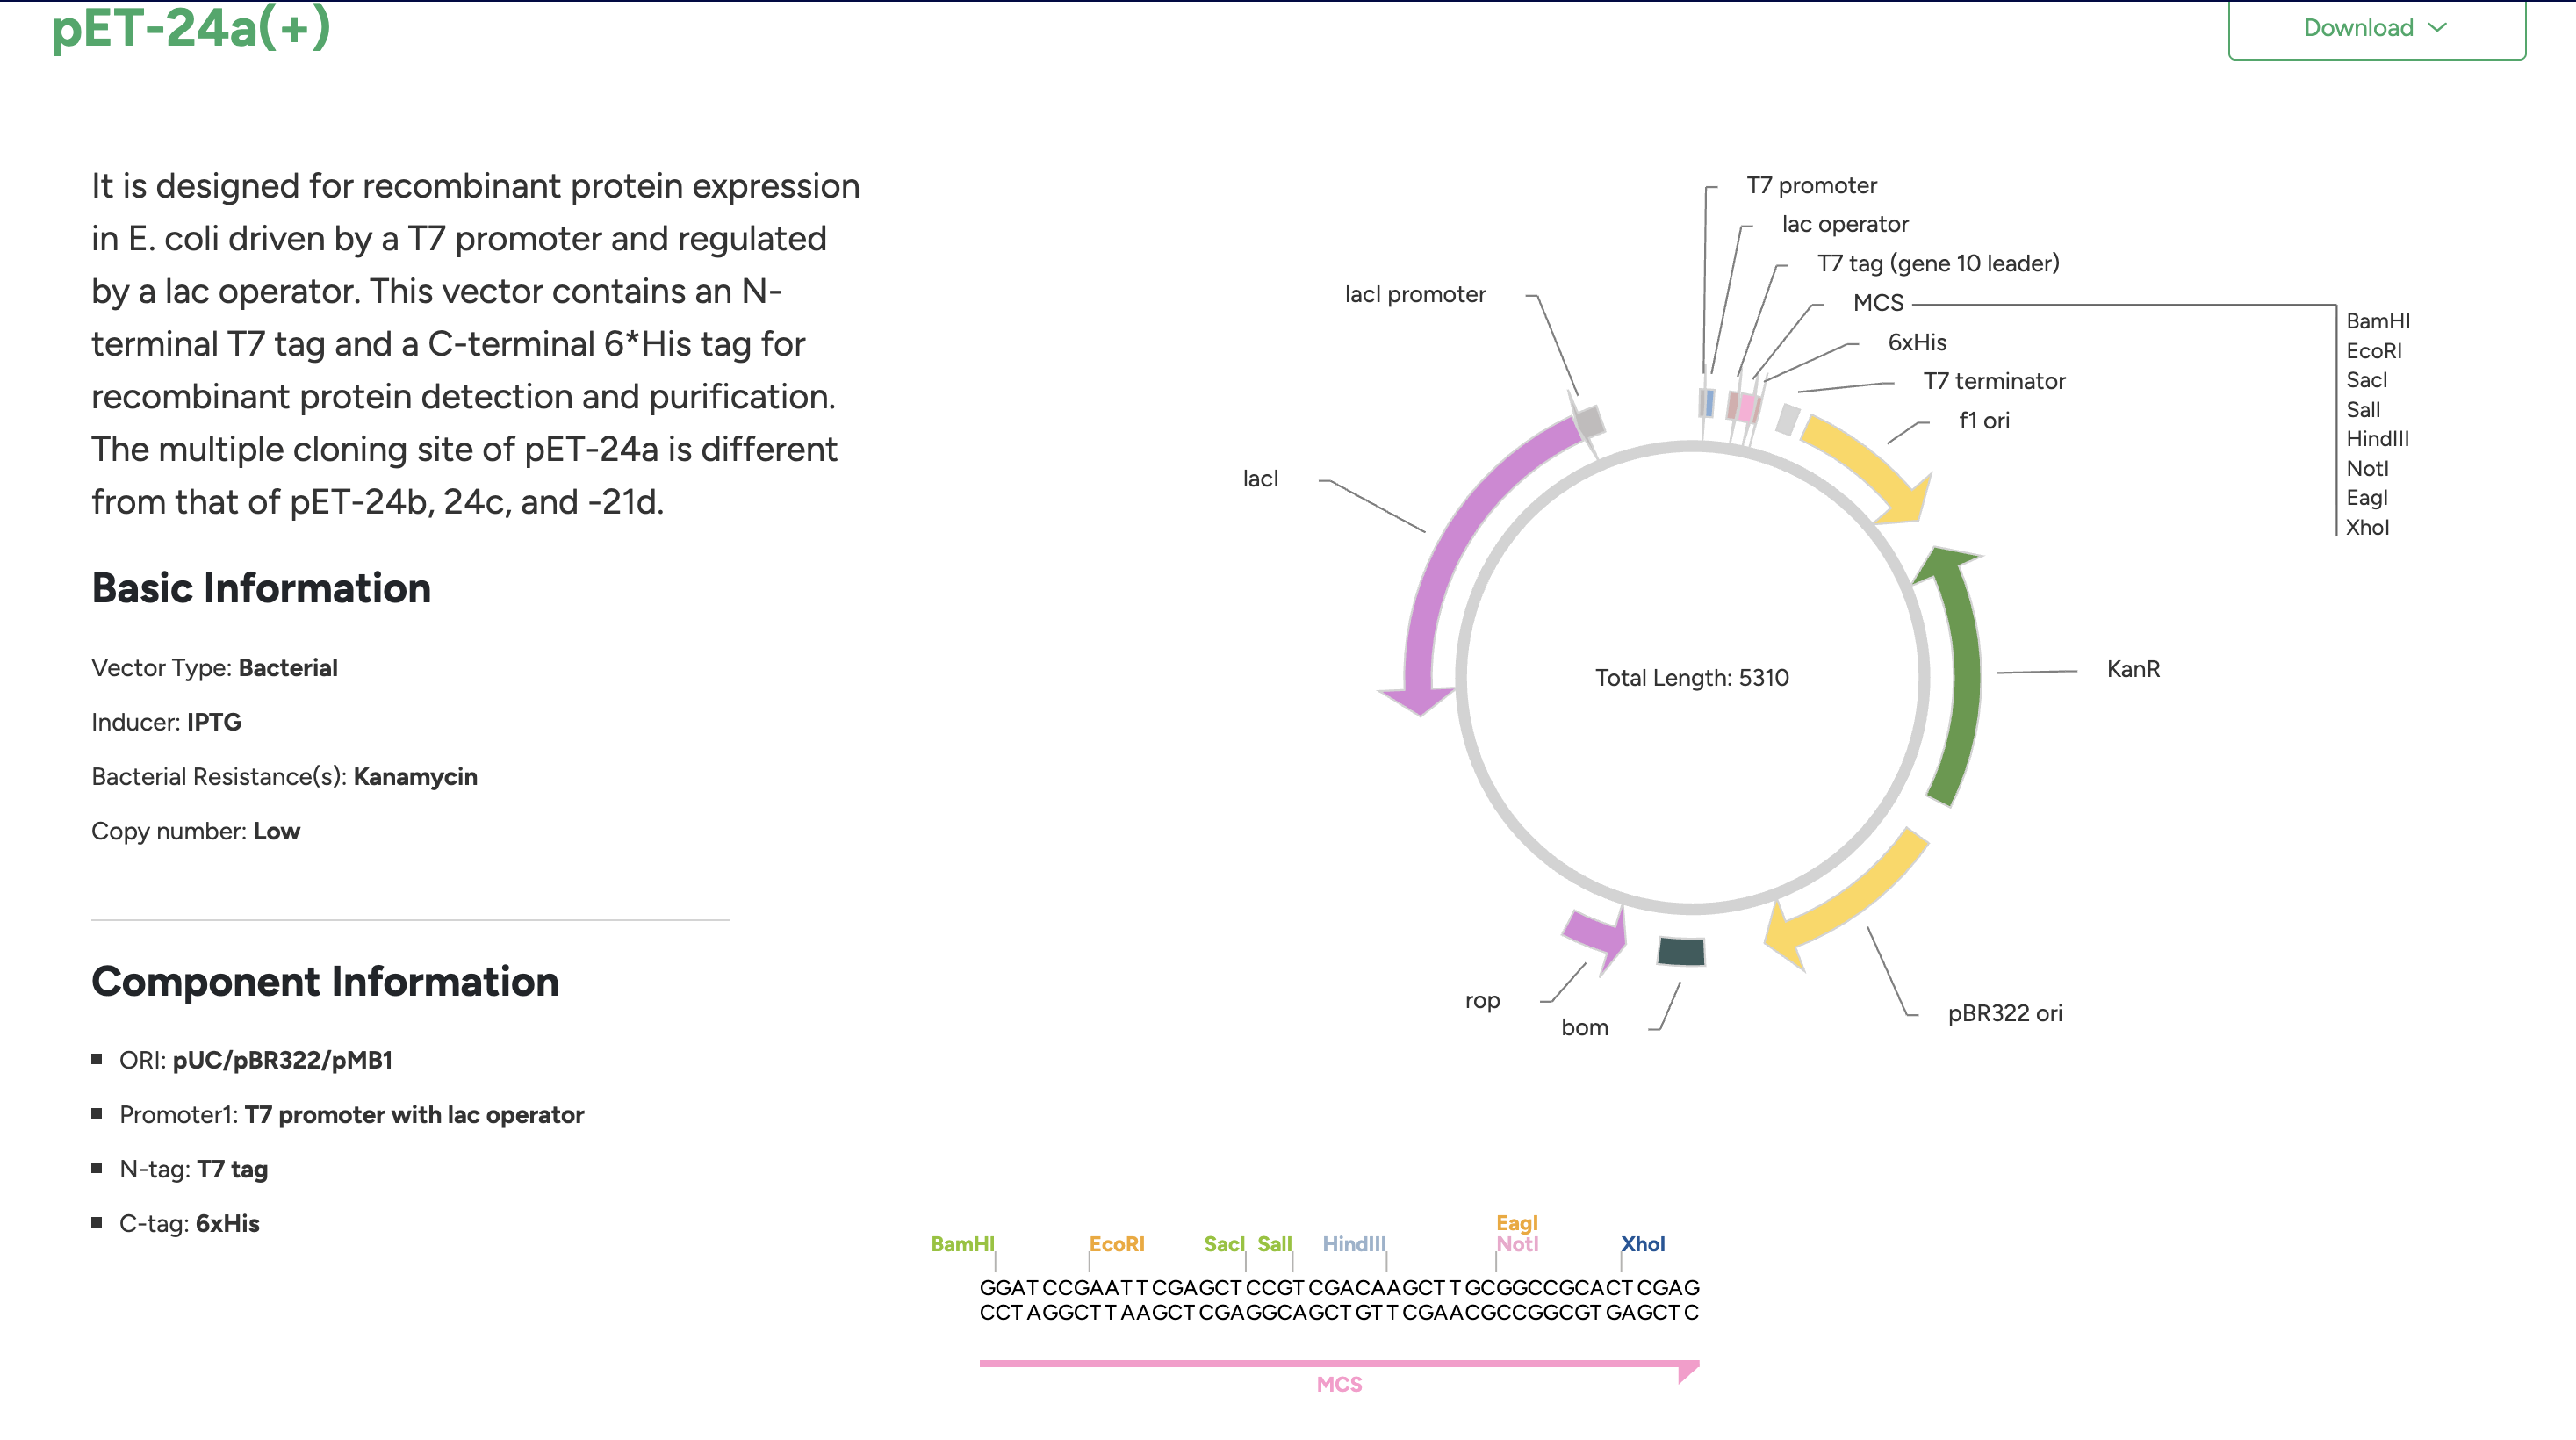

I've had to switch to Genscript, Twist won't ship to me. I'm considering their pET-24a(+) vector, which has a T7 promoter. I've set the 5' RE to EcoRI and the 3' to NotI. 

It's a low (medium?) copy plasmid. The T7 bit shouldn't play into things and can be ignored I think - I'm using MM294 and BL21, stains without DE3.

# Tree Frogs baby!

bicistronic operon is the plan.


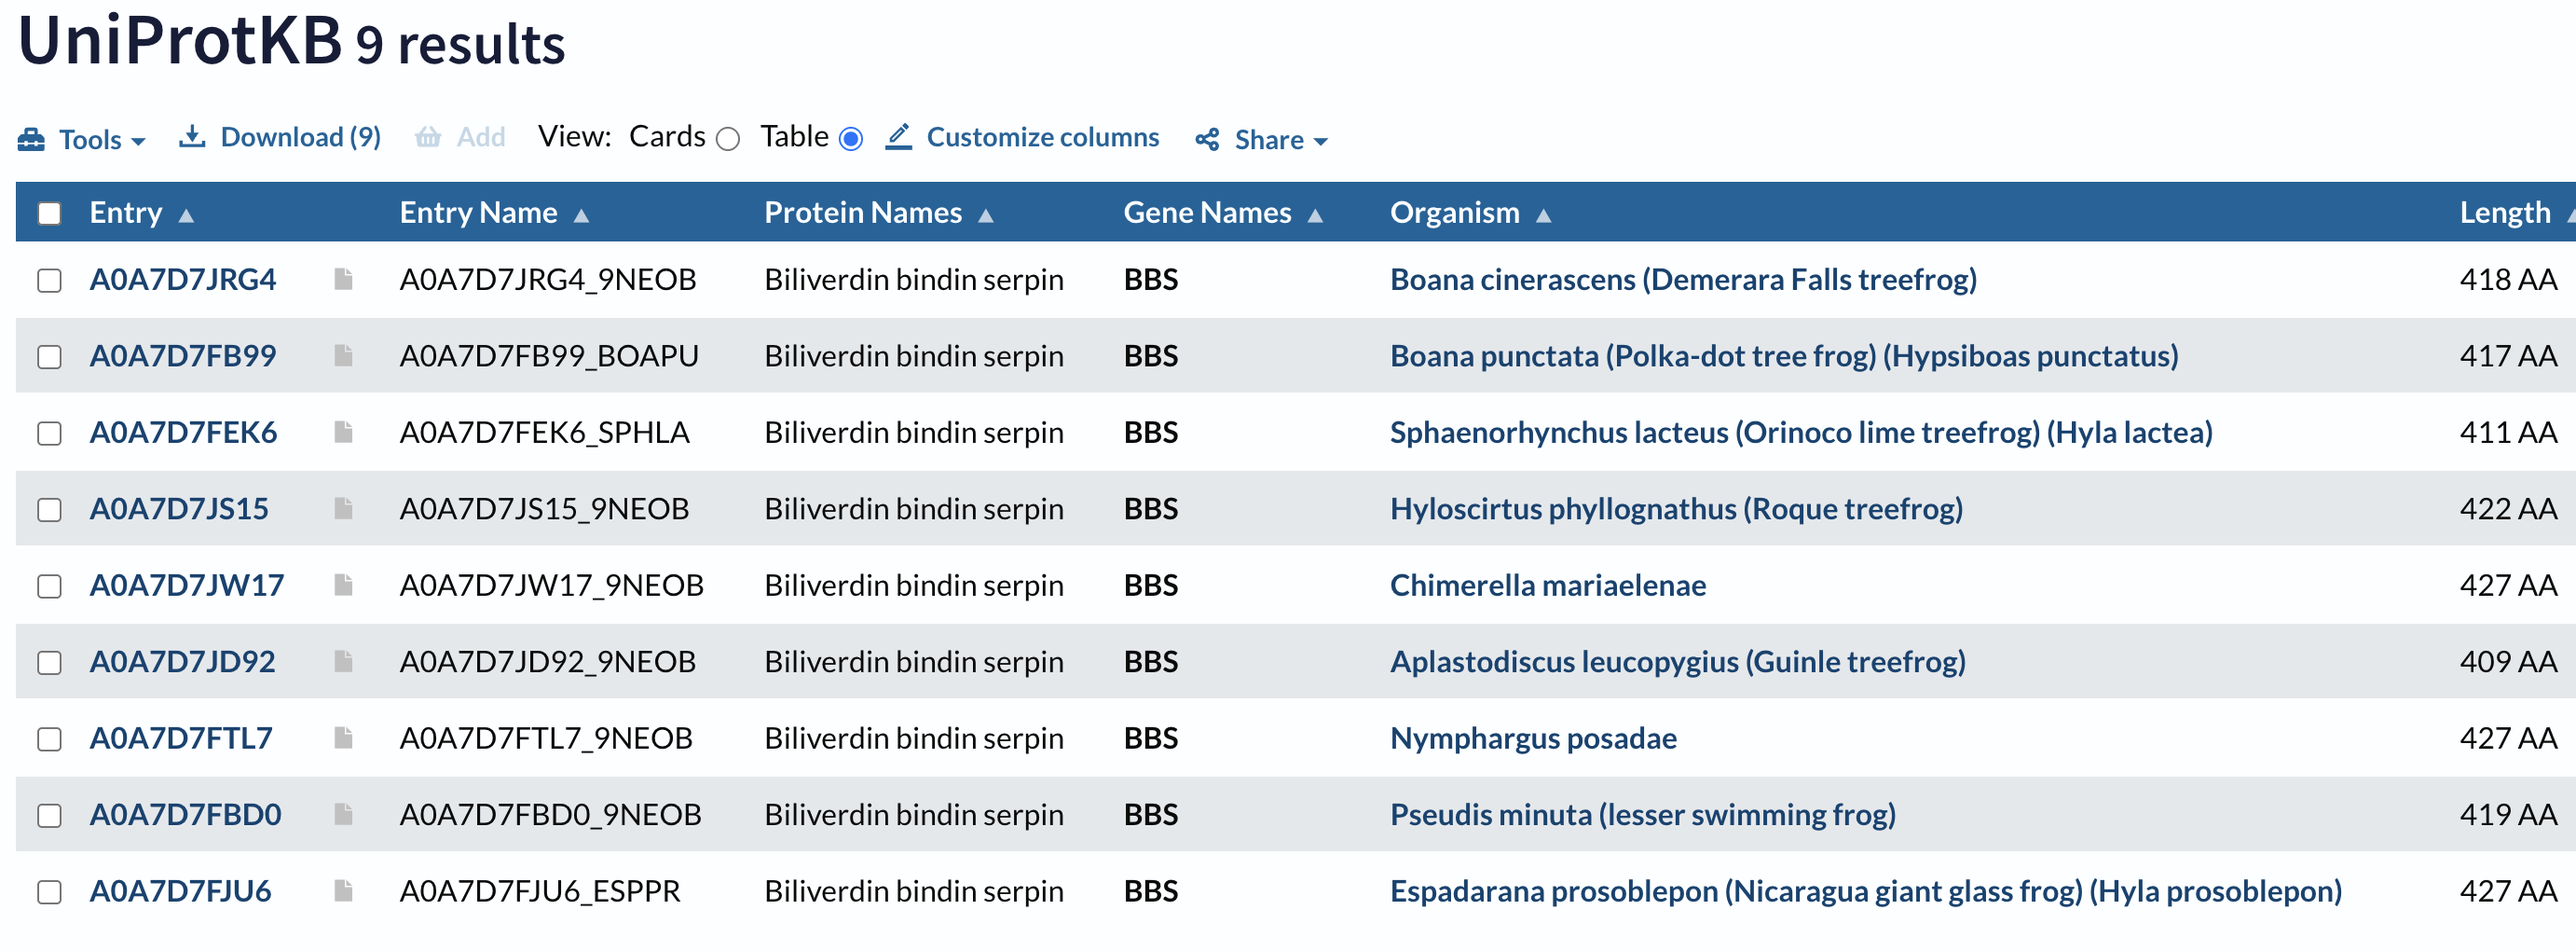

There are a few tree frogs to choose from!

Boana cinerascens (Demerara Falls treefrog) is the one I like from the pictures, let's use that.

In [ ]:
resp = httpx.get("https://rest.uniprot.org/uniprotkb/A0A7D7JRG4.fasta")
print(resp.text)

>tr|A0A7D7JRG4|A0A7D7JRG4_9NEOB Biliverdin bindin serpin OS=Boana cinerascens OX=2364978 GN=BBS PE=2 SV=1
MRVLLILGVVVLFTLAFAHHEEGHDDHKDDHDDLKDDHDPFFPEDKKRPFVYQKAAINNV
NFAFKMFRQVARDHPTGNIVISPVSISSALAFLSLXAKGHTHSQIIKGLGYNTSEISEQH
IHEGFHHQLDVMDDKDRHLEFEHGNAVFICEGHKIRQTFSDDAKRFYHSEAIPTDFKNTE
EAKNQINSYVEKHTHGKITNILDSVDQDDIFALINFIYFRGKWEHSFDEKLTKEGDFHVD
KDTTVKVPFMSRTGVYKVAYTDDIVIVTIPFNGSLEILFMMTELGKLSELELNLSRERSL
KWRDIMQYQKIEVTLPKFTISYNMDLKETLSKLGFEDIFSNNADLSGITDEAHLKVSEAV
HKAVMTVDEKGTEAAPAGEAAHLVHPGHVKFDCPFVFRLQDMITKNPLLVGRIDNPLK



NB: Mature BBS is apparently a glycoprotein...

In [ ]:
# # Fetch UniProt entry with cross-references to find the GenBank nucleotide accession
# resp = httpx.get("https://rest.uniprot.org/uniprotkb/A0A7D7JRG4.json")
# xrefs = [x for x in resp.json()['uniProtKBCrossReferences'] if x['database'] == 'EMBL']
# for x in xrefs:
#     print(x['id'], [p['value'] for p in x['properties']]) # MT358318 ['QMQ39191.1', '-', 'mRNA']

In [ ]:
resp = httpx.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi",
                 params={"db": "nuccore", "id": "MT358318", "rettype": "fasta", "retmode": "text"})
print(resp.text[:500])

>MT358318.1 Boana cinerascens biliverdin bindin serpin (BBS) mRNA, complete cds
ATGAGGGTCCTTCTGATCTTGGGAGTAGTTGTGCTTTTCACACTGGCCTTTGCTCATCATGAGGAGGGCC
ATGACGACCACAAAGACGACCATGACGACCTCAAAGACGACCATGACCCCTTTTTTCCCGAAGACAAAAA
AAGGCCCTTTGTATACCAAAAGGCAGCCATAAACAATGTCAATTTTGCCTTTAAAATGTTTCGGCAGGTG
GCTCGAGATCATCCTACTGGAAACATTGTCATCTCCCCTGTTAGTATCTCTTCAGCATTAGCTTTCCTGT
CCCTTGSCGCTAAGGGTCATACCCACTCACAGATCATTAAGGGATTGGGCTACAACACTTCTGAGATCTC
AGAGCAACACATTCATGAAGGTTTCCACCACCAACTGGATGTTATGGATGATAAGGACAGGCATT


In [ ]:
bbs_lines = resp.text.strip().split("\n")[1:]
bbs_nt = "".join(bbs_lines).upper()
print(f"Length: {len(bbs_nt)} bp")
print(f"Codons: {len(bbs_nt)//3}")
print(f"Translation:\n{Seq(bbs_nt).translate()}")

Length: 1257 bp
Codons: 419
Translation:
MRVLLILGVVVLFTLAFAHHEEGHDDHKDDHDDLKDDHDPFFPEDKKRPFVYQKAAINNVNFAFKMFRQVARDHPTGNIVISPVSISSALAFLSLXAKGHTHSQIIKGLGYNTSEISEQHIHEGFHHQLDVMDDKDRHLEFEHGNAVFICEGHKIRQTFSDDAKRFYHSEAIPTDFKNTEEAKNQINSYVEKHTHGKITNILDSVDQDDIFALINFIYFRGKWEHSFDEKLTKEGDFHVDKDTTVKVPFMSRTGVYKVAYTDDIVIVTIPFNGSLEILFMMTELGKLSELELNLSRERSLKWRDIMQYQKIEVTLPKFTISYNMDLKETLSKLGFEDIFSNNADLSGITDEAHLKVSEAVHKAVMTVDEKGTEAAPAGEAAHLVHPGHVKFDCPFVFRLQDMITKNPLLVGRIDNPLK*


"SL**X**AKG" -> Ambiguous protein, Ala or Gly. Let's check Polka-dot tree frog (Hypsiboas punctatus) and see, otherwise I'm happy enough subbing in Gly

In [ ]:
resp = httpx.get("https://rest.uniprot.org/uniprotkb/A0A7D7FB99.fasta")
print(resp.text)

>tr|A0A7D7FB99|A0A7D7FB99_BOAPU Biliverdin bindin serpin OS=Boana punctata OX=2499473 GN=BBS PE=1 SV=1
MRVLLILGVVVLSTLAFAHHEEGHHDHEDLKDDHDPFLPEDHKKALFVYQKPALNNINFA
FKMYRQLARDHPTENIVISPVSISSALALLSLGAKGHTHSQIVERLGYNTSEIPEQQIHE
SFHKQLDVVDDKDRDLEFEHGNALFTCKEHKIHQTFLDDAKKFYHSEVIPTDFKNTEEAK
NQINSYVEKSTHGKITNILDSVDQDAMIALINFIYLRANWQHPFDEKLTKEGDFHVDKDT
TVKVPFMRRRGIYKMAYTDDIIMVTIPYNGSVEMFLAMTKMGKLSELEQNLNRERSLKWR
EIMQYQLIDLSLPKLSVSGILNLKETLSKLGIVDVFSNHADLSGITDESHLKVSKAIHKA
MMSFDEHGTEAAPATAAEADPLMLPPHFKFDYPFIFRVQDLKTKNPLLVGRIANPQK



The polka-dot tree frog has SLGAKGHTH at that position — it's Glycine. So let's go with G. That means the ambiguous S base should be G, making the codon GGC.

In [ ]:
# Fix the ambiguous base and strip the signal peptide (first 18 aa = 54 nt)
bbs_fixed = bbs_nt.replace('S', 'G')
bbs_mature = "ATG" + bbs_fixed[54:]  # Add start codon, skip signal peptide
print(f"Mature BBS: {len(bbs_mature)} bp")
print(f"Translation: {Seq(bbs_mature).translate()}")

Mature BBS: 1206 bp
Translation: MHHEEGHDDHKDDHDDLKDDHDPFFPEDKKRPFVYQKAAINNVNFAFKMFRQVARDHPTGNIVISPVSISSALAFLSLGAKGHTHSQIIKGLGYNTSEISEQHIHEGFHHQLDVMDDKDRHLEFEHGNAVFICEGHKIRQTFSDDAKRFYHSEAIPTDFKNTEEAKNQINSYVEKHTHGKITNILDSVDQDDIFALINFIYFRGKWEHSFDEKLTKEGDFHVDKDTTVKVPFMSRTGVYKVAYTDDIVIVTIPFNGSLEILFMMTELGKLSELELNLSRERSLKWRDIMQYQKIEVTLPKFTISYNMDLKETLSKLGFEDIFSNNADLSGITDEAHLKVSEAVHKAVMTVDEKGTEAAPAGEAAHLVHPGHVKFDCPFVFRLQDMITKNPLLVGRIDNPLK*


In [ ]:
cassette_v2 = (J23100.seq + B0032.seq + spacer + ho1.seq 
               + B0034.seq + spacer + Seq(bbs_mature) + B0015.seq)
print(f"Cassette V2: {len(cassette_v2)} bp")
print(f"Breakdown: J23100({len(J23100)}) + B0032({len(B0032)}) + spacer(6) + ho1({len(ho1)}) + B0034({len(B0034)}) + spacer(6) + BBS({len(bbs_mature)}) + B0015({len(B0015)})")

Cassette V2: 2130 bp
Breakdown: J23100(35) + B0032(13) + spacer(6) + ho1(723) + B0034(12) + spacer(6) + BBS(1206) + B0015(129)


In [ ]:
print(cassette_v2)

ttgacggctagctcagtcctaggtacagtgctagctcacacaggaaagtactagATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCGGCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTACTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTACTTCCCCGAACTAAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGCAAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCCTGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAAATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACGAAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACGGATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTGATCAAGGCGATCGGCATTATGGTGTTCAACAGCCTCACCCGTCGCCGCAGTCAAGGCAGCACCGAAGTTGGCCTCGCCACCTCCGAAGGCTAGaaagaggagaaatactagATGCATCATGAGGAGGGCCATGACGACCACAAAGACGACCATGACGACCTCAAAGACGACCATGACCCCTTTTTTCCCGAAGACAAAAAAAGGCCCTTTGTATACCAAAAGGCAGCCATAAACAATGTCAATTTTGCCTTTAAAATGTTTCGGCAGGTGGCTCGAGATCATCCTACTGGAAACATTGTCATCTCCCCTGTTAGTA

In [ ]:
len(J23100.seq + B0032.seq + spacer + ho1.seq + B0034.seq + spacer)

795

I used genscript's online tool to codon optimize the bit for BBS, for e. coli. Copied in the resulting full seq here and pulling out the BBS:

In [ ]:
optimized_gene = "TTGACGGCTAGCTCAGTCCTAGGTACAGTGCTAGCTCACACAGGAAAGTACTAGATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCGGCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTACTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTACTTCCCCGAACTAAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGCAAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCCTGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAAATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACGAAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACGGATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTGATCAAGGCGATCGGCATTATGGTGTTCAACAGCCTCACCCGTCGCCGCAGTCAAGGCAGCACCGAAGTTGGCCTCGCCACCTCCGAAGGCTAGAAAGAGGAGAAATACTAGATGCACCACGAGGAAGGACATGATGACCACAAGGACGATCACGATGACCTGAAGGACGACCACGATCCGTTCTTCCCGGAAGATAAGAAACGTCCGTTTGTTTACCAAAAAGCTGCGATTAACAACGTTAATTTCGCTTTTAAGATGTTTCGCCAAGTGGCGCGTGACCACCCAACTGGTAATATTGTGATCTCCCCGGTTAGCATTTCCTCTGCACTGGCTTTCCTGAGCTTAGGCGCCAAAGGCCACACCCACTCGCAAATTATCAAAGGCCTGGGATACAACACGAGCGAGATCTCGGAGCAGCATATTCATGAAGGTTTCCATCATCAGCTGGATGTGATGGATGACAAGGATCGTCATTTGGAGTTCGAGCACGGGAACGCGGTCTTTATCTGTGAAGGCCATAAAATCCGCCAAACCTTTTCAGATGACGCAAAGCGCTTTTATCATTCTGAGGCCATCCCAACAGATTTCAAAAACACTGAGGAAGCTAAGAACCAGATCAATAGCTACGTTGAAAAACATACCCACGGCAAGATCACCAATATTCTGGATTCCGTGGACCAGGACGACATATTTGCGCTTATCAACTTTATCTACTTCAGAGGTAAGTGGGAACACAGCTTTGACGAGAAACTCACCAAAGAAGGTGATTTTCATGTTGACAAGGATACGACCGTAAAAGTTCCGTTCATGAGCCGTACCGGTGTTTACAAAGTTGCGTATACGGACGACATTGTCATCGTGACCATTCCGTTCAACGGTAGCTTGGAGATTCTGTTTATGATGACCGAACTGGGCAAGCTGTCTGAACTGGAGTTGAATCTGTCTCGTGAACGTAGCTTAAAGTGGCGTGACATCATGCAGTATCAAAAAATCGAAGTGACCCTGCCGAAATTCACCATCAGCTATAACATGGACCTCAAAGAAACCCTCTCCAAGCTGGGCTTTGAGGATATCTTCAGTAACAACGCCGACCTGAGCGGTATTACGGATGAGGCGCATCTGAAAGTGAGCGAGGCGGTGCACAAAGCTGTGATGACCGTCGACGAGAAGGGCACCGAGGCGGCACCGGCAGGTGAAGCGGCGCACTTGGTTCACCCGGGTCACGTGAAGTTCGATTGCCCGTTCGTCTTCCGCCTGCAGGATATGATTACGAAAAACCCGTTGCTGGTTGGTCGTATTGATAATCCGCTGAAGTAACCAGGCATCAAATAAAACGAAAGGCTCAGTCGAAAGACTGGGCCTTTCGTTTTATCTGTTGTTTGTCGGTGAACGCTCTCTACTAGAGTCACACTGGCTCACCTTCGGGTGGGCCTTTCTGCGTTTATA" # Warning EvoRV found in inner part of insert after optimization
optimized_BBS = optimized_gene[795:2001] # Region: 796 .. 2001    Length: 1206
len(optimized_BBS), optimized_BBS.startswith('ATG')

(1206, True)

OK, I think if I set the right restriction sites that EcoRV isn't going to be an issue. Can you give me code to create the final cassette and check it any way we can?

In [ ]:
from Bio import Restriction
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# Assemble final cassette from individual optimized parts
cassette_v2_opt = (J23100.seq + B0032.seq + spacer + ho1.seq 
                   + B0034.seq + spacer + Seq(optimized_BBS) + B0015.seq)

print(f"=== Cassette V2 (codon-optimized BBS) ===")
print(f"Total length: {len(cassette_v2_opt)} bp\n")

# Verify it matches the full optimized_gene
print(f"Matches optimized_gene: {str(cassette_v2_opt).upper() == optimized_gene.upper()}\n")

# Check HO1 ORF
ho1_start = len(J23100) + len(B0032) + len(spacer)
ho1_orf = cassette_v2_opt[ho1_start:ho1_start+len(ho1)]
print(f"HO1 ORF: {len(ho1_orf)} bp, starts with ATG: {str(ho1_orf).startswith('ATG')}")
print(f"HO1 translates correctly: {ho1_orf.translate(to_stop=True) == Seq(ho1_aa)}")

# Check BBS ORF
bbs_start = ho1_start + len(ho1) + len(B0034) + len(spacer)
bbs_orf = cassette_v2_opt[bbs_start:bbs_start+1206]
bbs_mature_aa = Seq(bbs_mature).translate(to_stop=True)
print(f"\nBBS ORF: {len(bbs_orf)} bp, starts with ATG: {str(bbs_orf).startswith('ATG')}")
print(f"BBS translates to same protein: {bbs_orf.translate(to_stop=True) == bbs_mature_aa}")
print(f"BBS mature protein: {len(bbs_mature_aa)} aa")

# Check for internal EcoRI (GAATTC) and NotI (GCGGCCGC) sites
seq_str = str(cassette_v2_opt).upper()
print(f"\n=== Restriction site check (cloning sites) ===")
print(f"Internal EcoRI (GAATTC): {seq_str.count('GAATTC')} sites")
print(f"Internal NotI (GCGGCCGC): {seq_str.count('GCGGCCGC')} sites")

# Check EcoRV just for info
print(f"Internal EcoRV (GATATC): {seq_str.count('GATATC')} sites")

# # Add flanking restriction sites for cloning # (Claude did this, but I think genscript do this in the webui)
# EcoRI_site = Seq("GAATTC")
# NotI_site = Seq("GCGGCCGC")
# final_insert = EcoRI_site + cassette_v2_opt + NotI_site
# print(f"\n=== Final insert with RE sites ===")
# print(f"Total length: {len(final_insert)} bp")

=== Cassette V2 (codon-optimized BBS) ===


Total length: 2130 bp

Matches optimized_gene: True

HO1 ORF: 723 bp, starts with ATG: True
HO1 translates correctly: True

BBS ORF: 1206 bp, starts with ATG: True
BBS translates to same protein: True
BBS mature protein: 401 aa

=== Restriction site check (cloning sites) ===
Internal EcoRI (GAATTC): 0 sites
Internal NotI (GCGGCCGC): 0 sites
Internal EcoRV (GATATC): 1 sites


In [ ]:
print(cassette_v2_opt)

ttgacggctagctcagtcctaggtacagtgctagctcacacaggaaagtactagATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCGGCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTACTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTACTTCCCCGAACTAAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGCAAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCCTGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAAATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACGAAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACGGATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTGATCAAGGCGATCGGCATTATGGTGTTCAACAGCCTCACCCGTCGCCGCAGTCAAGGCAGCACCGAAGTTGGCCTCGCCACCTCCGAAGGCTAGaaagaggagaaatactagATGCACCACGAGGAAGGACATGATGACCACAAGGACGATCACGATGACCTGAAGGACGACCACGATCCGTTCTTCCCGGAAGATAAGAAACGTCCGTTTGTTTACCAAAAAGCTGCGATTAACAACGTTAATTTCGCTTTTAAGATGTTTCGCCAAGTGGCGCGTGACCACCCAACTGGTAATATTGTGATCTCCCCGGTTAGCA

(They add the cloning sites, we don't add them to our insert afaik.)

Important finding in final checks: someone may have done this: https://www.sciencedirect.com/science/article/abs/pii/S0022283621005969 (extracts below)

Design of bacterial and mammalian plasmids
The gene encoding BpBBS (UniProt #A0A7D7FB99) without secretion signal peptide (residues 19–417) was codon-optimized for expression in mammalian cells and synthesized by GenScript. For expression in mammalian cells, the BpBBS gene was cloned between BglII and EcoRI sites in the backbone of pEGFP-N1 plasmid (Clontech) with EGFP gene removed by blunted BamHI-NotI sites. To produce BpBBS in E. coli, the codon-optimized gene was inserted in the BglII and EcoRI sites of the pBAD/His-B vector
Data availability
The main data supporting the findings of this study are available within the article and its Supplementary Information. Additional data are available from the corresponding author. The BpBBS structural data were deposited at the Protein Data Bank (PDB ID: 7RBW)

This is good news re: glycolization not being vital

If I want to:

In [ ]:
# # Check for internal restriction sites in cassette (before adding flanks)
# seq_upper = str(cassette_v2_opt).upper()
# print("Internal RE sites in cassette:")
# for name, site in [("EcoRI", "GAATTC"), ("NotI", "GCGGCCGC"),
#                     ("HindIII", "AAGCTT"), ("BamHI", "GGATCC"),
#                     ("XhoI", "CTCGAG"), ("EcoRV", "GATATC"),
#                     ("SacI", "GAGCTC"), ("SalI", "GTCGAC")]:
#     count = seq_upper.count(site)
#     flag = " ⚠️" if count > 0 else " ✓"
#     print(f"  {name} ({site}): {count}{flag}")

In [ ]:
# # Standard clamp + RE site flanking
# ecori_flank = "AAGCTT" + "GAATTC"   # HindIII clamp + EcoRI (or just use AAAA as clamp)
# noti_flank  = "GCGGCCGC" + "AAGCTT"  # NotI + HindIII clamp

# final_insert = Seq(ecori_flank) + cassette_v2_opt + Seq(noti_flank)
# print(f"Final insert length: {len(final_insert)} bp")
# print(f"EcoRI site present: {str(final_insert).upper().count('GAATTC')}")
# print(f"NotI site present:  {str(final_insert).upper().count('GCGGCCGC')}")

In [ ]:
# Removing that EcoRV just in case
# Fix EcoRV site: GAT->GAC (synonymous Asp substitution)
fixed = str(cassette_v2_opt).upper()
fixed = fixed[:1752] + "GAC" + fixed[1755:]
cassette_v2_final = Seq(fixed)

# Verify
print(f"EcoRV sites remaining: {fixed.count('GATATC')}")

# Check BBS protein unchanged
bbs_orf_fixed = cassette_v2_final[bbs_start:bbs_start+1206]
print(f"BBS protein unchanged: {bbs_orf_fixed.translate(to_stop=True) == bbs_mature_aa}")

EcoRV sites remaining: 0
BBS protein unchanged: True


In [ ]:
final_insert = cassette_v2_final

print(final_insert)

TTGACGGCTAGCTCAGTCCTAGGTACAGTGCTAGCTCACACAGGAAAGTACTAGATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCGGCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTACTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTACTTCCCCGAACTAAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGCAAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCCTGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAAATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACGAAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACGGATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTGATCAAGGCGATCGGCATTATGGTGTTCAACAGCCTCACCCGTCGCCGCAGTCAAGGCAGCACCGAAGTTGGCCTCGCCACCTCCGAAGGCTAGAAAGAGGAGAAATACTAGATGCACCACGAGGAAGGACATGATGACCACAAGGACGATCACGATGACCTGAAGGACGACCACGATCCGTTCTTCCCGGAAGATAAGAAACGTCCGTTTGTTTACCAAAAAGCTGCGATTAACAACGTTAATTTCGCTTTTAAGATGTTTCGCCAAGTGGCGCGTGACCACCCAACTGGTAATATTGTGATCTCCCCGGTTAGCA

**OK, I did some final checks then hit order. $250 inc shipping (~50) and glycerol stock (10, but also then ship with a bunch of dry ice which is fun). This is probably my last attempt at this, here's hoping!**